In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import HelmholtzBiperiodic
import HelmholtzChannel
import Chebyshev

# Tests des solveurs de Helmholtz
## Cas périodique


On résout 
$$
(\partial_x^2 + \partial_y^2 -\alpha^2)\psi = S
$$
Avec $x\in [0, 2\pi]$, $y \in [0, 2\pi]$, $\alpha^2 = 2$. Pour $\psi(x, y) = \cos{2x}\sin{2y}$, cela donne 
$$
(-(4+4)-2)\psi = -10\psi = S
$$
D'où $S = -10\cos{2x}\sin{2y}$

x_inf = 0.0, x_sup = 6.234097921967246
y_inf = 0.0, y_sup = 6.234097921967246
x_sup =x[-1] = 6.185394031951877, x_inf =x[0] = 0.0
y_sup =y[-1] = 6.185394031951877, y_inf =y[0] = 0.0
kx = [  0.           1.01581003   2.03162006   3.04743009   4.06324013
   5.07905016   6.09486019   7.11067022   8.12648025   9.14229028
  10.15810032  11.17391035  12.18972038  13.20553041  14.22134044
  15.23715047  16.25296051  17.26877054  18.28458057  19.3003906
  20.31620063  21.33201066  22.3478207   23.36363073  24.37944076
  25.39525079  26.41106082  27.42687085  28.44268089  29.45849092
  30.47430095  31.49011098  32.50592101  33.52173104  34.53754108
  35.55335111  36.56916114  37.58497117  38.6007812   39.61659123
  40.63240126  41.6482113   42.66402133  43.67983136  44.69564139
  45.71145142  46.72726145  47.74307149  48.75888152  49.77469155
  50.79050158  51.80631161  52.82212164  53.83793168  54.85374171
  55.86955174  56.88536177  57.9011718   58.91698183  59.93279187
  60.9486019   61.9644

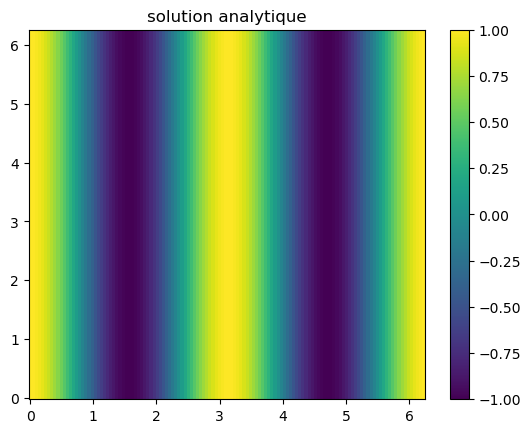

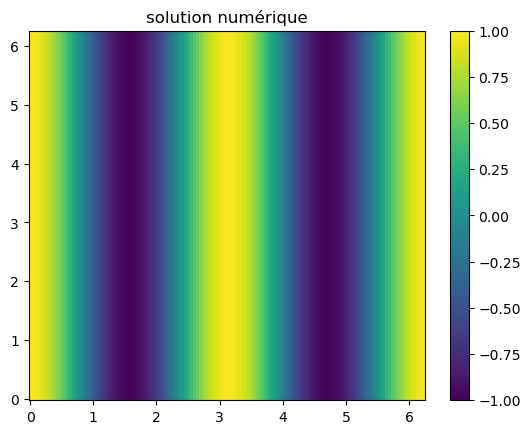

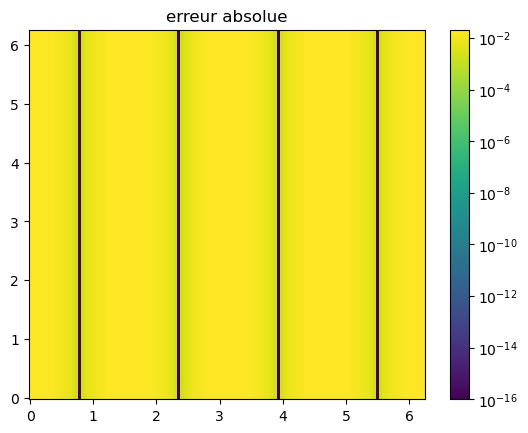

In [3]:
Nx = 128
Ny = 128

x = np.linspace(0.0, 2.0*np.pi, Nx, endpoint = False)
y = np.linspace(0.0, 2.0*np.pi, Ny, endpoint = False)

print(f"x_inf = {x[0]}, x_sup = {x[-1]}")
print(f"y_inf = {y[0]}, y_sup = {y[-1]}")

X, Y = np.meshgrid(x, y, indexing= 'ij')

k = 2.0
l=2.0


#rhs = -6.0*np.cos(2.0*X)

alpha2 = 2.0
#rhs = (-k**2-l**2-alpha2)*np.cos(k*X)*np.sin(l*Y)
#sol_ana = np.cos(k*X)*np.sin(l*Y)
rhs = (-k**2-alpha2)*np.cos(k*X)
sol_ana = np.cos(k*X)


Fourier_solver = HelmholtzBiperiodic.HelmholtzBiperiodic(Nx, Ny, x_bounds = (x[0], x[-1]), y_bounds = (y[0], y[-1]), alpha2 = alpha2)
sol_num = Fourier_solver.Solve(rhs)

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, sol_ana, vmin = -1.0, vmax = 1.0)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y,sol_num, vmin = -1.0, vmax = 1.0)
fig.colorbar(cf, ax=ax)

err = np.abs(sol_ana - sol_num)
print(f"err {err}, min = {err.min()}, max = {err.max()}, mediane = {np.median(err)}")

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err, norm=colors.LogNorm(vmin=1.0e-16, vmax=err.max()))
fig.colorbar(cf, ax=ax)

kx = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]
ky  = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62

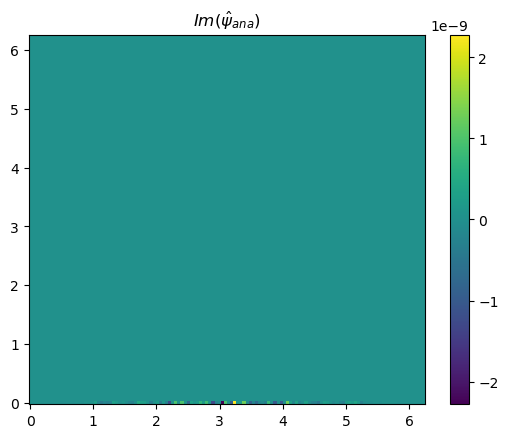

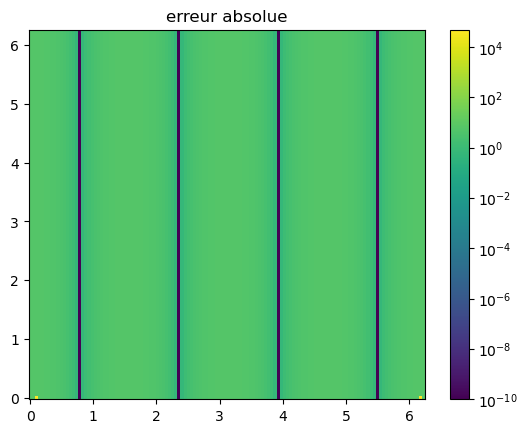

In [4]:
import scipy

dx = 2.0*np.pi/Nx
dy = 2.0*np.pi/Ny
kx = 2.0*np.pi*scipy.fft.fftfreq(Ny, d = dx)
ky = 2.0*np.pi*scipy.fft.fftfreq(Ny, d = dy)

KX, KY = np.meshgrid(kx, ky, indexing = 'ij')

KX2 = -KX**2
KY2 = -KY**2


print(f"kx = {kx}")
print(f"ky  = {ky}")
sol_ana_hat = scipy.fft.fft2(sol_ana)
#print(f"Sol_ana_hat = {sol_ana_hat}")
rhs_hat = (KX2+KY2-alpha2)*sol_ana_hat
rhs_real = scipy.fft.ifft2(rhs_hat).real

ax=plt.axes()
ax.set_title(r"$Im(\hat{\psi}_{ana})$")
cf = ax.pcolormesh(X, Y, rhs_hat.imag)
fig.colorbar(cf, ax=ax)


print(f"rhs_real = {rhs_real}")
print(f"rhs = {rhs}")
fig = plt.figure()
ax=plt.axes()
err_rhs = np.abs(rhs_hat - rhs_real)
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-10, vmax=err_rhs.max()))
fig.colorbar(cf, ax=ax)

In [5]:
sol_ana_hat

array([[-6.38864997e-13-0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00-0.00000000e+00j, ...,
         0.00000000e+00-0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00-0.00000000e+00j],
       [-8.77794995e-13+2.16194459e-13j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         0.00000000e+00-0.00000000e+00j,  0.00000000e+00-0.00000000e+00j,
         0.00000000e+00-0.00000000e+00j],
       [ 8.19200000e+03-2.08852165e-12j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         0.00000000e+00-0.00000000e+00j,  0.00000000e+00-0.00000000e+00j,
         0.00000000e+00-0.00000000e+00j],
       ...,
       [ 4.29267128e-13+1.92758994e-13j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         0.00000000e+00-0.00000000e+00j,  0.00000000e+00-0.00000000e+00j,
         0.00000000e+00-0.00000000e+00j],
       [ 8.19200000e+03+2.08852165e-12j,  0.

## Configuration "canal"

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \cosh(l)\cos(kx)$. La solution est $\psi(x, y) = \cos(kx)\cosh(ly)$ pour $\alpha^2 = k^2-l^2$ et $RHS = \left(l^2 -k^2 - \alpha^2\right)\cos{kx}\cosh{ly}$
Ici, $\alpha^2 = 3$, $k=2$, $l=1$, ce qui donne $RHS = -6\cos{kx}\cosh{ly}$

Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0
Solveur choisi : HelmholtzChannel
Calcul des matrices de différenciation et préfactorisation LU
Fait en 0.036 s
Mémoire occupée par ces matrices : 15.57 MiB
Appel HelmholtzChannel
Fait en 0.008 s
erreur min = 0.0, max = 1.192379528447418e-13, mediane = 1.4432899320127035e-14


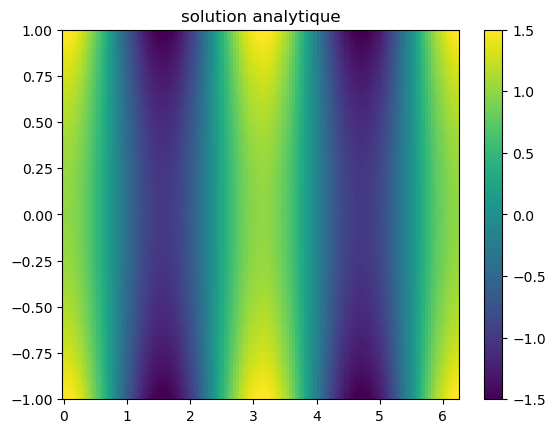

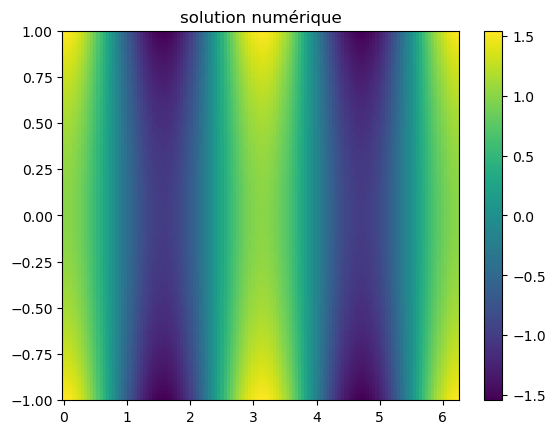

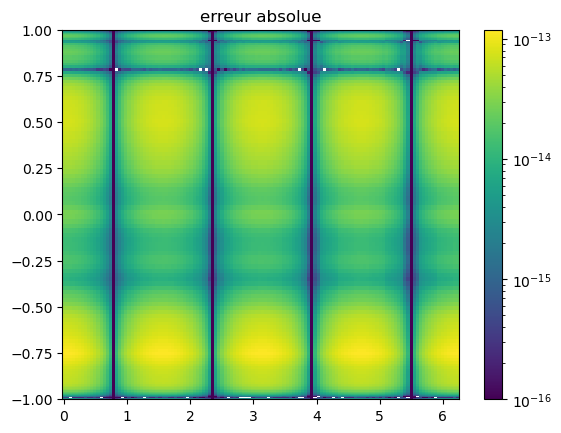

In [6]:
Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2_2 = 3.0

print(f'alpha^2 {alpha2}')

bc_y1_2 = np.cos(k*x)*np.cosh(l)
bc_ym1_2 = np.cos(k*x)*np.cosh(l)

psi_analytique_2 = np.cos(k*X)*np.cosh(l*Y)
#psi_analytique_2 = np.cos(k*X)*np.sinh(l*Y)

rhs_2 = (l**2-k**2-alpha2_2)*np.cos(k*X)*np.cosh(l*Y)
#rhs_2 = -6.0*np.cos(k*X)*np.sinh(l*Y)
#rhs_2 = np.zeros((Nx, Ny))
ChannelSolver = HelmholtzChannel.HelmholtzChannel(Nx, Ny, x_bounds = (x_inf, x_sup), y_bounds = (y_inf, y_sup), alpha2 = alpha2_2)
psi_num_2 = ChannelSolver.Solve(rhs_2, bc_ym1_2, bc_y1_2)

VMAX = max(psi_analytique_2.max(), psi_num_2.max())
VMIN = min(psi_analytique_2.min(), psi_num_2.min())

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique_2, vmin = -1.5, vmax = 1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num_2, vmin = VMIN, vmax = VMAX)
fig.colorbar(cf, ax=ax)

err_2 = np.abs(psi_analytique_2 - psi_num_2)
print(f"erreur min = {err_2.min()}, max = {err_2.max()}, mediane = {np.median(err_2)}")
fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)